# Day 58: Decision Tree — Entropy & Information Gain Theory
**Phase 4 · Machine Learning** | Dataset: a 12-match FC Lahore Lions toy table (small enough to calculate by hand)

## Objective
By the end of this notebook I should be able to:
- Describe **tree structure**: root, decision nodes, leaf nodes
- Calculate **entropy** `H = -Σ p·log₂(p)` and explain why 0 means a pure node
- Calculate **information gain** = entropy(parent) − weighted entropy(children), **by hand**
- Use information gain to choose which feature to split on at each node

> Today is theory and hand calculation. Using sklearn's `DecisionTreeClassifier` properly is Day 59.

## Imports

In [1]:
# numpy for log2, pandas for the toy table, matplotlib for charts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.grid"] = True

## Theory
- **A decision tree is a flowchart of yes/no questions.** Each question splits the data on **one feature**.
  - **Root node:** the first question, using all the data.
  - **Decision node:** a later question inside a branch.
  - **Leaf node:** the end of a branch. It gives the final prediction (the majority class).
- **Which question should come first?** The one that makes the groups *cleaner* (more one-sided).
- **Entropy** measures how mixed (impure) a node is: `H = -Σ p · log₂(p)`
  - `p` is the share of each class in the node.
  - **Pure node** (all one class): `H = 0`. **Perfect 50/50 mix** (two classes): `H = 1`.
- **Information gain (IG)** = `entropy(parent) − weighted average of entropy(children)`.
  - "Weighted" means each child counts in proportion to its size.
  - At every node, the tree picks the split with the **highest IG**.
- We define `0 · log₂(0) = 0`, so a pure node has entropy 0.

**Football picture:** entropy is how unpredictable the result is for a group of matches. A group where the team always wins is predictable (H = 0). A group that is half wins and half losses is a coin flip (H = 1). A good question, like "were shots on target high?", splits the matches into groups that are easier to call.

## Example 1: Toy Dataset and Entropy

In [2]:
# Toy dataset: 12 FC Lahore Lions matches
# shots = shots on target (High/Low), home = played at home (Yes/No), won = result
toy = pd.DataFrame({
    "match_id": range(1, 13),
    "shots": ["High", "High", "High", "High", "High", "High",
              "Low", "Low", "Low", "Low", "Low", "Low"],
    "home":  ["Yes", "Yes", "No", "No", "Yes", "No",
              "Yes", "Yes", "No", "No", "No", "Yes"],
    "won":   ["Win", "Win", "Win", "Loss", "Win", "Win",
              "Win", "Loss", "Loss", "Loss", "Loss", "Loss"],
})

# Save next to the notebook, then read it back
toy.to_csv("day_58_toy_matches.csv", index=False)
toy = pd.read_csv("day_58_toy_matches.csv")

print(toy)
print()
print(toy["won"].value_counts())

    match_id shots home   won
0          1  High  Yes   Win
1          2  High  Yes   Win
2          3  High   No   Win
3          4  High   No  Loss
4          5  High  Yes   Win
5          6  High   No   Win
6          7   Low  Yes   Win
7          8   Low  Yes  Loss
8          9   Low   No  Loss
9         10   Low   No  Loss
10        11   Low   No  Loss
11        12   Low  Yes  Loss

won
Win     6
Loss    6
Name: count, dtype: int64


In [3]:
# Entropy from class counts, e.g. [wins, losses]
def entropy(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]    # skip zero counts (0 * log2(0) = 0)
    return sum(-p * np.log2(p) for p in probs)      # same as -sum(p * log2(p))

print("Pure node, 6 wins 0 losses:", entropy([6, 0]))
print("Even mix, 3 wins 3 losses: ", entropy([3, 3]))
print("Mostly wins, 5 wins 1 loss:", round(entropy([5, 1]), 3))

Pure node, 6 wins 0 losses: 0.0
Even mix, 3 wins 3 losses:  1.0
Mostly wins, 5 wins 1 loss: 0.65


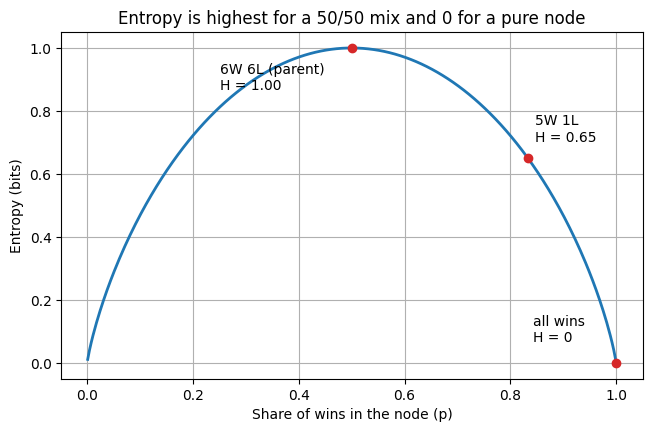

In [4]:
# Chart: entropy of a two-class node as the share of wins p changes
p = np.linspace(0.001, 0.999, 300)
h = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

plt.figure(figsize=(7.5, 4.5))
plt.plot(p, h, linewidth=2)
plt.scatter([0.5, 5 / 6, 1.0], [1.0, entropy([5, 1]), 0.0], color="tab:red", zorder=3)
plt.annotate("6W 6L (parent)\nH = 1.00", (0.5, 1.0), textcoords="offset points", xytext=(-95, -30))
plt.annotate("5W 1L\nH = 0.65", (5 / 6, entropy([5, 1])), textcoords="offset points", xytext=(5, 12))
plt.annotate("all wins\nH = 0", (1.0, 0.0), textcoords="offset points", xytext=(-60, 15))
plt.xlabel("Share of wins in the node (p)")
plt.ylabel("Entropy (bits)")
plt.title("Entropy is highest for a 50/50 mix and 0 for a pure node")
plt.savefig("images/entropy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Example 2: Information Gain, by Hand and in Code

### 2A. By hand: splitting on Shots

In [5]:
# Parent node: 12 matches = 6 wins + 6 losses
parent = entropy([6, 6])                  # 1.0, a perfect 50/50 mix

# Children after splitting on shots
high = entropy([5, 1])                    # Shots High: 6 matches, 5 wins 1 loss
low = entropy([1, 5])                     # Shots Low:  6 matches, 1 win 5 losses

# Weighted average: each child counts by its share of the matches (6 of 12 each)
weighted = (6 / 12) * high + (6 / 12) * low

print("Parent entropy:  ", round(parent, 3))
print("Weighted children:", round(weighted, 3))
print("Information gain:", round(parent - weighted, 3))

Parent entropy:   1.0
Weighted children: 0.65
Information gain: 0.35


### 2B. By hand: splitting on Home

In [6]:
# Home = Yes: 6 matches -> 4 wins, 2 losses. Home = No: 6 matches -> 2 wins, 4 losses.
home_yes = entropy([4, 2])
home_no = entropy([2, 4])
weighted_home = (6 / 12) * home_yes + (6 / 12) * home_no

print("Home=Yes entropy:", round(home_yes, 3))
print("Home=No entropy: ", round(home_no, 3))
print("Information gain:", round(entropy([6, 6]) - weighted_home, 3))

Home=Yes entropy: 0.918
Home=No entropy:  0.918
Information gain: 0.082


### 2C. The same thing as a reusable function

In [7]:
# Information gain for splitting a DataFrame on one column
def info_gain(df, col, target):
    parent = entropy(df[target].value_counts())
    weighted = 0
    for _, part in df.groupby(col):
        w = len(part) / len(df)                          # this child's share of the rows
        weighted += w * entropy(part[target].value_counts())
    return parent - weighted

# Same answer as the by-hand calculation for Shots
print(round(info_gain(toy, "shots", "won"), 3))

0.35


In [8]:
# Rank the candidate root splits
for col in ["shots", "home"]:
    gain = info_gain(toy, col, "won")
    print(col, round(gain, 3))

# The highest gain wins, so Shots becomes the ROOT node

shots 0.35
home 0.082


### 2D. Second level: keep splitting inside a branch

In [9]:
# Only the matches with Shots = High (5 wins, 1 loss)
high_df = toy[toy["shots"] == "High"]
print(len(high_df), "matches")
print("Entropy of this branch:", round(entropy(high_df["won"].value_counts()), 3))
print("Gain from splitting on Home:", round(info_gain(high_df, "home", "won"), 3))

# Same for the Shots = Low branch
low_df = toy[toy["shots"] == "Low"]
print("\nLow branch entropy:", round(entropy(low_df["won"].value_counts()), 3))
print("Gain from splitting on Home:", round(info_gain(low_df, "home", "won"), 3))

6 matches
Entropy of this branch: 0.65
Gain from splitting on Home: 0.191

Low branch entropy: 0.65
Gain from splitting on Home: 0.191


### 2E. The finished tree, as a diagram

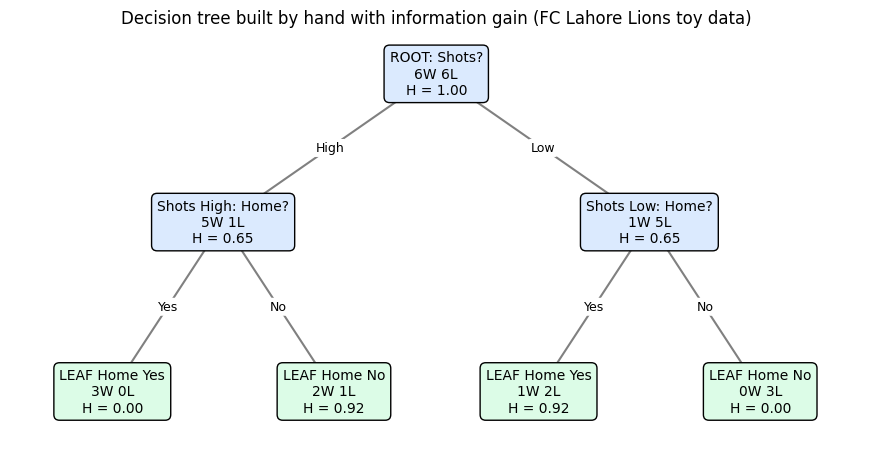

In [10]:
# Helper: text for one node = counts + entropy
def node_text(df, title):
    counts = df["won"].value_counts()
    w, l = counts.get("Win", 0), counts.get("Loss", 0)
    return f"{title}\n{w}W {l}L\nH = {entropy(counts):.2f}"

hi = toy[toy["shots"] == "High"]
lo = toy[toy["shots"] == "Low"]
nodes = {
    "root": (0.50, 0.90, node_text(toy, "ROOT: Shots?")),
    "hi":   (0.25, 0.55, node_text(hi, "Shots High: Home?")),
    "lo":   (0.75, 0.55, node_text(lo, "Shots Low: Home?")),
    "hiY":  (0.12, 0.15, node_text(hi[hi["home"] == "Yes"], "LEAF Home Yes")),
    "hiN":  (0.38, 0.15, node_text(hi[hi["home"] == "No"], "LEAF Home No")),
    "loY":  (0.62, 0.15, node_text(lo[lo["home"] == "Yes"], "LEAF Home Yes")),
    "loN":  (0.88, 0.15, node_text(lo[lo["home"] == "No"], "LEAF Home No")),
}
edges = [("root", "hi", "High"), ("root", "lo", "Low"), ("hi", "hiY", "Yes"),
         ("hi", "hiN", "No"), ("lo", "loY", "Yes"), ("lo", "loN", "No")]

fig, ax = plt.subplots(figsize=(11, 5.5))
# Lines run centre to centre; the boxes are drawn on top and hide the line ends
for a, b, branch in edges:
    ax.plot([nodes[a][0], nodes[b][0]], [nodes[a][1], nodes[b][1]], color="grey", zorder=1)
    mid_x = (nodes[a][0] + nodes[b][0]) / 2
    mid_y = (nodes[a][1] + nodes[b][1]) / 2
    ax.text(mid_x, mid_y, branch, ha="center", va="center", fontsize=9, zorder=3,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none"))
for key, (x, y, text) in nodes.items():
    colour = "#dbeafe" if key in ("root", "hi", "lo") else "#dcfce7"
    ax.text(x, y, text, ha="center", va="center", fontsize=10, zorder=2,
            bbox=dict(boxstyle="round,pad=0.4", facecolor=colour, edgecolor="black"))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Decision tree built by hand with information gain (FC Lahore Lions toy data)")
plt.savefig("images/tree_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## Practice Exercise
**Your turn (Practice).** 8 matches: 4 wins and 4 losses. Splitting on **"key striker fit?"** gives:
- Fit: 4 matches, **3 wins, 1 loss**
- Not fit: 4 matches, **1 win, 3 losses**

1. Write the parent entropy by hand.
2. Write the entropy of each child.
3. Calculate the weighted entropy and the information gain.

In [11]:
# Your attempt here

In [12]:
# Worked answer
parent_p = entropy([4, 4])            # 1.0
fit = entropy([3, 1])                 # -(3/4)log2(3/4) - (1/4)log2(1/4)
not_fit = entropy([1, 3])             # same numbers, mirrored
weighted_p = (4 / 8) * fit + (4 / 8) * not_fit

print("Parent:", round(parent_p, 3))
print("Fit:", round(fit, 3), "| Not fit:", round(not_fit, 3))
print("Information gain:", round(parent_p - weighted_p, 3))

Parent: 1.0
Fit: 0.811 | Not fit: 0.811
Information gain: 0.189


## Mini Challenge
**Build the whole tree with recursion.** Write `build_tree(df, features)` that:
1. Stops (makes a **leaf**) if the node is pure or no features are left, and prints the majority class.
2. Otherwise picks the feature with the highest information gain, prints it, and repeats on each branch with that feature removed.

In [13]:
# Mini Challenge solution
def build_tree(df, features, target="won", indent=0, label=""):
    counts = df[target].value_counts()
    wins, losses = counts.get("Win", 0), counts.get("Loss", 0)
    prefix = "  " * indent + (f"{label} -> " if label else "")

    # Leaf: pure node, or nothing left to split on
    if entropy(counts) == 0 or not features:
        print(f"{prefix}{counts.idxmax()} ({wins}W {losses}L)")
        return

    # Decision node: choose the feature with the highest information gain
    gains = {f: info_gain(df, f, target) for f in features}
    best = max(gains, key=gains.get)
    print(f"{prefix}{best.capitalize()}?")

    # Recurse into each branch without the used feature
    remaining = [f for f in features if f != best]
    for value, part in df.groupby(best):
        build_tree(part, remaining, target, indent + 1, value)

build_tree(toy, ["shots", "home"])

Shots?
  High -> Home?
    No -> Win (2W 1L)
    Yes -> Win (3W 0L)
  Low -> Home?
    No -> Loss (0W 3L)
    Yes -> Loss (1W 2L)


In [14]:
# Optional check (preview of Day 59): does sklearn agree with my hand calculation?
from sklearn.tree import DecisionTreeClassifier

X_check = pd.DataFrame({
    "shots_high": (toy["shots"] == "High").astype(int),
    "home_yes": (toy["home"] == "Yes").astype(int),
})
tree = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=42)
tree.fit(X_check, toy["won"])

print("Root split chosen by sklearn:", X_check.columns[tree.tree_.feature[0]])
print("Entropy at root and children:", tree.tree_.impurity.round(3))

Root split chosen by sklearn: shots_high
Entropy at root and children: [1.   0.65 0.65]


## Summary
- A tree is a series of yes/no questions: **root**, **decision nodes**, **leaf nodes**.
- **Entropy** `-Σ p·log₂(p)` measures how mixed a node is. Pure = 0. A 50/50 two-class mix = 1.
- **Information gain** = parent entropy − weighted child entropy. The tree picks the split with the highest gain.
- On the toy data, Shots gave a gain of 0.35 and Home only 0.082, so **Shots is the root**.
- A tree keeps splitting until nodes are pure or stopping rules apply. Too many splits can overfit.
- **Next: Day 59 — Decision Tree in sklearn + visualization.**